# Aircraft Classification — La soluzione migliore, spiegata
### IP&CV Part 2 · Modulo 2 · FGVC-Aircraft (100 varianti di velivoli)

Questo notebook **consolida** il percorso sperimentale del Modulo 2 in un'unica soluzione
di riferimento, spiegando ogni scelta e ancorandola al materiale del corso (lezioni **L5 —
architetture** e **L6 — regolarizzazione & training recipes**). Dove un componente **non è
coperto dalle slide**, la scelta è giustificata con il **paper di riferimento** (evidenziato
in <span style="color:#b00">rosso</span> nel testo e raccolto nella tabella di coerenza in fondo).

**Modello vincitore:** `12_combo_deep` (from-scratch, ResNet-like), **calibrato** con il
protocollo di training lungo `long_wd`.

| Metrica | Valore |
|---|---|
| **Test accuracy** | **62.47 %** |
| Validation accuracy | 62.68 % |
| Target dell'assignment | ≥ 50 % sul test ✅ **superato** |
| Parametri | 8.07 M |
| Baseline from-scratch | 20.31 % val |

Il notebook segue il metodo scientifico richiesto dall'assignment: **(1)** una baseline
pulita, **(2)** un *ablation study* controllato a **variabile singola** che misura l'impatto
di ogni scelta architetturale, **(3)** la combinazione dei soli componenti vincenti, e **(4)**
la calibrazione degli iperparametri sull'architettura congelata. Ogni numero mostrato è
caricato dagli artefatti reali salvati durante gli esperimenti (`sandbox/architecture_ablation/`);
le celle non ri-allenano nulla, ma i comandi per riprodurre i run sono riportati.

## 0 · Setup

Il codice della soluzione vive in due package del progetto, che questo notebook **riusa**
invece di duplicare:

- `cnn_library/` — dataset e utilità di training;
- `sandbox/architecture_ablation/` — le varianti dell'ablation (`models.py`), il runner
  controllato (`run_experiments.py`) e la calibrazione (`calibrate.py`).

Eseguire il notebook dalla **root del progetto** (`computer-vision-project/`), così che gli
import `cnn_library...` e `sandbox...` si risolvano.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Rende importabili i package del progetto quando si esegue dalla root.
ROOT = Path.cwd()
if not (ROOT / "sandbox").exists() and (ROOT.parent / "sandbox").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

ABL = ROOT / "sandbox" / "architecture_ablation"
assert ABL.exists(), f"Cartella ablation non trovata a partire da {ROOT}"

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})
print("Root del progetto:", ROOT.name)
print("Package importabili:", (ROOT / "cnn_library").exists() and (ROOT / "sandbox").exists())

Root del progetto: computer-vision-project
Package importabili: True


### Mappa del codice — riferimenti alla libreria

Questo notebook **non riscrive** la soluzione: la riusa dai package del progetto. Ogni
componente descritto qui sotto è referenziato al suo file e simbolo, e più avanti il **sorgente
reale** viene mostrato inline con `inspect.getsource` (nessuna duplicazione, sempre in sync
con la libreria).

| Componente | File | Simbolo |
|---|---|---|
| Dataset + crop copyright + cache | `cnn_library/data.py` | `FGVCAircraftDataset`, `ensure_fgvc_aircraft` |
| Augmentation / transforms | `sandbox/refinements/resnet_aircraft_experiment.py` | `build_transforms` |
| Blocchi residui (post/pre-activation) | `sandbox/architecture_ablation/models.py` | `PostActBlock`, `PreActBlock` |
| **GeM pooling** | `sandbox/architecture_ablation/models.py` | `GeMPool` |
| Modello configurabile + spec varianti | `sandbox/architecture_ablation/models.py` | `ConfigurableAircraftResNet`, `SPECS`, `build_model` |
| Loop di training/eval, seed, conteggio param | `sandbox/refinements/resnet_aircraft_experiment.py` | `run_epoch`, `set_seed`, `count_parameters` |
| Runner ablation controllato | `sandbox/architecture_ablation/run_experiments.py` | `StudyConfig`, `train_variant`, `evaluate_winner` |
| Calibrazione iperparametri | `sandbox/architecture_ablation/calibrate.py` | `CONFIGS`, `train_config` |

In [2]:
import inspect
from IPython.display import Code, display

def show_src(*objs, header=None):
    # Mostra il sorgente reale della libreria (con evidenziazione), citando file e riga.
    if header:
        print(header)
    blocks = []
    for obj in objs:
        try:
            src = inspect.getsource(obj)
            file = Path(inspect.getsourcefile(obj)).relative_to(ROOT)
            line = inspect.getsourcelines(obj)[1]
            blocks.append(f"# --- {file} : {getattr(obj, '__name__', obj)}  (riga {line}) ---\n{src}")
        except (TypeError, OSError) as exc:
            blocks.append(f"# (sorgente non disponibile per {obj}: {exc})")
    display(Code("\n\n".join(blocks), language="python"))

## 1 · Il problema: classificazione *fine-grained*

FGVC-Aircraft chiede di distinguere **100 varianti** di velivolo (es. `Boeing 737-700` vs
`737-800`) da appena **~3 300 immagini di training** (split `train`; `val` e `test` ~3 300
ciascuno). È un problema **fine-grained**: le classi condividono una silhouette quasi
identica e differiscono per **dettagli locali minuscoli** — numero di motori, forma del muso,
presenza di *winglet*, livrea. Due conseguenze guidano l'intero progetto:

1. **Servono feature locali ad alta risoluzione** e un modo per *concentrarle* sulle regioni
   discriminanti → motiva lo **stem a 3 conv 3×3** (preserva dettaglio) e il **GeM pooling**.
2. **Pochi dati ⇒ overfitting severo** → motiva l'intera batteria di regolarizzazione di L6
   (weight decay, label smoothing, dropout, data augmentation, early stopping).

Nota sul dato: la striscia inferiore di ogni immagine è un **banner di copyright** stampato
dagli autori del dataset, non parte della foto — va rimossa prima di tutto (vedi `data.py`,
`COPYRIGHT_BAR_PX = 20`).

## 2 · Dati e pipeline di augmentation

Il dataset (`cnn_library/data.py`, classe `FGVCAircraftDataset`) per ogni immagine: la
decodifica, **ritaglia il banner di copyright**, la ridimensiona a 256×256 e la converte in
tensore (con una cache opzionale in memoria condivisa per velocizzare i `DataLoader` su
Windows). Le trasformazioni di training/eval (`sandbox/refinements/resnet_aircraft_experiment.py`,
`build_transforms`) operano poi sul tensore:

**Train (augmentation — tutta materia L6):**
- `RandomResizedCrop(224, scale=(0.65,1.0))` — crop multi-scala: varia scala/posizione,
  costringe il modello a non memorizzare l'inquadratura. *(L6: data augmentation multi-scala.)*
- `RandomHorizontalFlip` — simmetria plausibile per un velivolo di profilo.
- `ColorJitter` lieve — robustezza a luce/livrea.
- `RandomErasing(p=0.20)` — occlusione casuale, regolarizzatore forte su dataset piccoli.
  *(L6: Random Erasing, Zhong et al. AAAI 2020.)*
- `Normalize` con media/σ ImageNet — standardizza gli input. *(L4/L6.)*

**Eval:** solo `Resize(224)` + `Normalize`, deterministico.

Tutti questi elementi sono **coperti dal corso (L6)**: nessuna citazione esterna necessaria.

In [3]:
from cnn_library.data import COPYRIGHT_BAR_PX
from sandbox.refinements.resnet_aircraft_experiment import build_transforms, IMAGENET_MEAN, IMAGENET_STD

train_tf, eval_tf = build_transforms(image_size=224)
print("Copyright bar rimossa (px):", COPYRIGHT_BAR_PX)
print("ImageNet mean/std:", IMAGENET_MEAN, IMAGENET_STD)
print("\nTrain transform:\n", train_tf)
print("\nEval transform:\n", eval_tf)

Copyright bar rimossa (px): 20
ImageNet mean/std: (0.485, 0.456, 0.406) (0.229, 0.224, 0.225)

Train transform:
 Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.65, 1.0), ratio=(0.85, 1.2), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.88, 1.12), hue=(-0.02, 0.02))
    RandomErasing(p=0.2, scale=(0.02, 0.08), ratio=(0.3, 3.3), value=0.0, inplace=False)
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)

Eval transform:
 Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


**Sorgente della libreria** — dataset (crop copyright + cache) e pipeline di augmentation:

In [4]:
from cnn_library.data import FGVCAircraftDataset
show_src(FGVCAircraftDataset, header="# Dataset")
show_src(build_transforms, header="# Augmentation / transforms")

# Dataset


# --- cnn_library\data.py : FGVCAircraftDataset  (riga 87) ---
class FGVCAircraftDataset(Dataset):
    """FGVC-Aircraft dataset, labeled by variant.

    Each `images_variant_{split}.txt` file already lists exactly the images
    belonging to that split together with their variant label, so it alone
    is enough to recover both the train/val/test membership and the class
    of every image (no need to cross-reference `images_{split}.txt`).
    """

    def __init__(self, root, split="train", transform=None, download=True, cache=False):
        root = ensure_fgvc_aircraft(root, download=download)
        data_dir = root / "data"
        self.images_dir = data_dir / "images"
        self.samples = _parse_variant_file(data_dir, split)

        self.cache_enabled = cache
        if cache:
            # When caching, `transform` runs on the cached float tensor instead of
            # a PIL image, so we skip STD_SHAPING's Resize/ToTensor here: the cache
            # already stores the resized 256x256 image, and __getitem__ does the
            # /255 that ToTensor would. Result is numerically equivalent, just fast.
            self.post_transform = transform
            self._build_cache()
        else:
            self.transform = (
                STD_SHAPING if transform is None else T.Compose([STD_SHAPING, transform])
            )

    def _build_cache(self):
        """Decode+crop+resize every image once into a shared-memory uint8 tensor.

        Shared memory lets DataLoader workers (spawned on Windows) map the same
        buffer instead of each pickling a private copy. Stored as uint8 to keep
        the footprint at ~1/4 of the float tensor (~0.6 GB per 3.3k-image split).
        """
        resize = T.Resize((256, 256))
        count = len(self.samples)
        cache = torch.empty((count, 3, 256, 256), dtype=torch.uint8)
        labels = torch.empty(count, dtype=torch.long)
        for i, (filename, label) in enumerate(self.samples):
            image = Image.open(self.images_dir / f"{filename}.jpg").convert("RGB")
            width, height = image.size
            image = image.crop((0, 0, width, height - COPYRIGHT_BAR_PX))
            cache[i] = pil_to_tensor(resize(image))
            labels[i] = label
        self.cache_images = cache.share_memory_()
        self.cache_labels = labels.share_memory_()

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        if self.cache_enabled:
            image = self.cache_images[index].float().div_(255.0)
            if self.post_transform is not None:
                image = self.post_transform(image)
            return image, int(self.cache_labels[index])

        filename, label = self.samples[index]
        image_path = self.images_dir / f"{filename}.jpg"

        image = Image.open(image_path).convert("RGB")
        width, height = image.size
        image = image.crop((0, 0, width, height - COPYRIGHT_BAR_PX))

        if self.transform is not None:
            image = self.transform(image)

        return image, label

# Augmentation / transforms


# --- sandbox\refinements\resnet_aircraft_experiment.py : build_transforms  (riga 197) ---
def build_transforms(image_size: int) -> tuple[object, object]:
    from torchvision import transforms as T

    # FGVCAircraftDataset already crops the copyright strip, resizes to 256,
    # and converts to tensor. These transforms therefore operate on tensors.
    train_transform = T.Compose(
        [
            T.RandomResizedCrop(
                (image_size, image_size),
                scale=(0.65, 1.0),
                ratio=(0.85, 1.20),
                antialias=True,
            ),
            T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.12, hue=0.02),
            T.RandomErasing(p=0.20, scale=(0.02, 0.08), ratio=(0.3, 3.3), value=0.0),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )
    eval_transform = T.Compose(
        [
            T.Resize((image_size, image_size), antialias=True),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )
    return train_transform, eval_transform

## 3 · L'architettura vincente: `12_combo_deep`

È una ResNet compatta *from-scratch* (nessuna rete pre-istanziata: costruita da layer PyTorch,
come richiesto dall'assignment). Definita in `sandbox/architecture_ablation/models.py` come
`ConfigurableAircraftResNet` con lo spec:

```python
ModelSpec("12_combo_deep",
          layers=(2, 3, 4, 2),           # profondità per stage  → "deeper"
          channels=(48, 96, 192, 384),   # larghezza per stage   → "wider"
          preactivation=True,            # blocco pre-activation  → OLTRE IL CORSO
          gem_pool=True,                 # Generalized Mean pool  → OLTRE IL CORSO
          mlp_head=True)                 # testa MLP non lineare
```

Pipeline: **stem → 4 stage residuali → GeM pool → testa MLP**.

**Stem (3× conv 3×3, stride 2 poi 1,1).** Tre 3×3 al posto di un 7×7 conservano più
dettaglio locale a parità di *receptive field* — è la variante **ResNet-C** del *Bag of
Tricks*. *(Coperto dal corso, L5.)*

**Stage residuali — `layers=(2,3,4,2)`, `channels=(48,96,192,384)`.** Blocchi residui con
scorciatoia identità/proiezione (He et al., CVPR 2016). Due leve di capacità, entrambe
**nominate nel corso** (L5/L6):
- **larghezza** (`wider`, 32→48 … 256→384): in isolamento **+5.4** punti;
- **profondità** (`deeper`, +1 blocco negli stage centrali): in isolamento solo **+1.0**.

Sul nostro dataset piccolo *allargare* rende molto più che *approfondire*, coerente con la
tesi delle **Wide Residual Networks** (Zagoruyko & Komodakis, BMVC 2016): a parità di budget,
la larghezza dà miglior accuratezza-per-parametro ed è più facile da addestrare, specie con
pochi dati. Il corso nomina la larghezza come leva; il paper è il riferimento della tesi
"width > depth".

**<span style="color:#b00">GeM pooling — OLTRE IL CORSO.</span>** Il corso insegna il *global
average pooling* (GAP). Qui lo sostituiamo con la **media generalizzata**
$f_k = \left(\tfrac{1}{|X_k|}\sum_{x\in X_k} x^{\,p}\right)^{1/p}$ con **`p` apprendibile**
(init 3.0, clampato in [1,8]). I casi estremi sono noti: `p=1`→average, `p→∞`→max. Con `p>1`
il pooling **enfatizza le attivazioni salienti** (motore, coda) senza scartare del tutto il
contesto: esattamente ciò che serve nel fine-grained, dove l'average diluisce il segnale utile
nello sfondo comune a tutte le classi. In isolamento vale **+5.9 punti con un solo parametro
in più** — il miglior rapporto impatto/costo dello studio.
> **Paper:** F. Radenović, G. Tolias, O. Chum, *Fine-tuning CNN Image Retrieval with No Human
> Annotation*, **IEEE TPAMI 2019** (arXiv:1711.02512) — introduce il GeM per il retrieval
> fine-grained. Radici teoriche del pooling: Boureau et al., *A theoretical analysis of feature
> pooling*, ICML 2010.

**Testa MLP non lineare.** Sostituisce `Dropout→Linear(384,100)` con un collo di bottiglia
`Linear(384→512)→BatchNorm1d→ReLU→Dropout(0.4)→Linear(512→100)`. Una testa **lineare** impone
confini di decisione lineari: su classi fine-grained vicine e non separabili linearmente è un
collo di bottiglia. Il layer nascosto + ReLU permette confini **non lineari**; BatchNorm
stabilizza, Dropout(0.4) regolarizza. In isolamento è il **vincitore singolo: +11.4 punti**.
Le teste multi-FC sono nel corso (AlexNet/VGG, L5) e l'idea "1×1 conv = MLP per posizione"
(NiN, L5); evidenza aggiuntiva sul beneficio di una *projection head* MLP non lineare:
Chen et al., **SimCLR**, ICML 2020 (arXiv:2002.05709). BatchNorm (Ioffe & Szegedy, ICML 2015)
e Dropout (Srivastava et al., JMLR 2014) sono trattati in L6.

**<span style="color:#b00">Pre-activation — OLTRE IL CORSO (dettaglio).</span>** Il blocco
riordina `BN→ReLU→Conv` (ResNet-v2) per un flusso di gradiente più pulito nelle reti profonde.
In isolamento è **neutro** (−0.24) e infatti **non** entra in `11_combo_core`; lo adottiamo
**solo nella variante profonda** `12_combo_deep`, dove stabilizza la rete più profonda e
contribuisce all'incremento finale — non lo rivendichiamo come vincitore a sé.
> **Paper:** K. He, X. Zhang, S. Ren, J. Sun, *Identity Mappings in Deep Residual Networks*,
> **ECCV 2016** (arXiv:1603.05027).

In [5]:
import torch
from sandbox.architecture_ablation.models import build_model, SPECS
from sandbox.refinements.resnet_aircraft_experiment import count_parameters

model = build_model("12_combo_deep")
n_params = count_parameters(model)

# Forward "dry-run" su un batch casuale: verifica shape e conteggio parametri (CPU, veloce).
model.eval()
with torch.no_grad():
    y = model(torch.randn(2, 3, 224, 224))

print("Spec:", SPECS["12_combo_deep"])
print(f"\nOutput shape: {tuple(y.shape)}  (batch=2, 100 classi)")
print(f"Parametri addestrabili: {n_params:,}")

# Il pooling è GeM con p apprendibile
print("GeM p (init):", float(model.pool.p.detach()))

Spec:

 ModelSpec(name='12_combo_deep', layers=(2, 3, 4, 2), channels=(48, 96, 192, 384), preactivation=True, use_se=False, delayed_downsampling=False, dilated_stage4=False, gem_pool=True, mlp_head=True, multiscale=False)

Output shape: (2, 100)  (batch=2, 100 classi)
Parametri addestrabili: 8,068,597
GeM p (init): 3.0


**Sorgente della libreria** — i due elementi *oltre il corso* (`GeMPool`, `PreActBlock`), il
blocco standard (`PostActBlock`) e il modello configurabile che li assembla secondo lo `SPECS`:

In [6]:
from sandbox.architecture_ablation.models import (
    GeMPool, PreActBlock, PostActBlock, ConfigurableAircraftResNet,
)
show_src(GeMPool, header="# GeM pooling  [OLTRE IL CORSO — Radenovic et al., TPAMI 2019]")
show_src(PreActBlock, PostActBlock, header="# Blocchi residui (pre-activation [OLTRE IL CORSO] e post-activation)")
show_src(ConfigurableAircraftResNet, header="# Modello configurabile")

# GeM pooling  [OLTRE IL CORSO — Radenovic et al., TPAMI 2019]


# --- sandbox\architecture_ablation\models.py : GeMPool  (riga 28) ---
class GeMPool(nn.Module):
    def __init__(self, p: float = 3.0, eps: float = 1e-6) -> None:
        super().__init__()
        self.p = nn.Parameter(torch.tensor(p))
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        p = self.p.clamp(min=1.0, max=8.0)
        return F.adaptive_avg_pool2d(x.clamp(min=self.eps).pow(p), 1).pow(1.0 / p)

# Blocchi residui (pre-activation [OLTRE IL CORSO] e post-activation)


# --- sandbox\architecture_ablation\models.py : PreActBlock  (riga 61) ---
class PreActBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dilation=1, use_se=False, dropout=0.05):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, dilation, dilation=dilation, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout) if dropout else nn.Identity()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, dilation, dilation=dilation, bias=False)
        self.se = SqueezeExcitation(out_channels) if use_se else nn.Identity()
        self.projection = nn.Conv2d(in_channels, out_channels, 1, stride, bias=False) if stride != 1 or in_channels != out_channels else None

    def forward(self, x):
        pre = F.relu(self.bn1(x), inplace=True)
        identity = self.projection(pre) if self.projection is not None else x
        out = self.conv1(pre)
        out = self.dropout(F.relu(self.bn2(out), inplace=True))
        return self.se(self.conv2(out)) + identity


# --- sandbox\architecture_ablation\models.py : PostActBlock  (riga 39) ---
class PostActBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dilation=1, use_se=False, dropout=0.05):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, dilation, dilation=dilation, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout) if dropout else nn.Identity()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, dilation, dilation=dilation, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SqueezeExcitation(out_channels) if use_se else nn.Identity()
        self.shortcut = (
            nn.Sequential(nn.Conv2d(in_channels, out_channels, 1, stride, bias=False), nn.BatchNorm2d(out_channels))
            if stride != 1 or in_channels != out_channels else nn.Identity()
        )

    def forward(self, x):
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.dropout(out)
        out = self.se(self.bn2(self.conv2(out)))
        return F.relu(out + identity, inplace=True)

# Modello configurabile


# --- sandbox\architecture_ablation\models.py : ConfigurableAircraftResNet  (riga 122) ---
class ConfigurableAircraftResNet(nn.Module):
    def __init__(self, spec: ModelSpec, num_classes: int = 100, head_dropout: float = 0.35):
        super().__init__()
        self.spec = spec
        block = PreActBlock if spec.preactivation else PostActBlock
        channels = spec.channels
        self.in_channels = channels[0]
        self.stem = nn.Sequential(
            nn.Conv2d(3, channels[0], 3, 2, 1, bias=False), nn.BatchNorm2d(channels[0]), nn.ReLU(inplace=True),
            nn.Conv2d(channels[0], channels[0], 3, 1, 1, bias=False), nn.BatchNorm2d(channels[0]), nn.ReLU(inplace=True),
            nn.Conv2d(channels[0], channels[0], 3, 1, 1, bias=False), nn.BatchNorm2d(channels[0]), nn.ReLU(inplace=True),
        )
        strides = (1, 1 if spec.delayed_downsampling else 2, 2, 1 if spec.dilated_stage4 else 2)
        dilations = (1, 1, 1, 2 if spec.dilated_stage4 else 1)
        self.stages = nn.ModuleList([
            self._make_stage(block, c, n, s, d, spec.use_se)
            for c, n, s, d in zip(channels, spec.layers, strides, dilations)
        ])
        self.pool = GeMPool() if spec.gem_pool else nn.AdaptiveAvgPool2d(1)
        feature_dim = channels[-1] + (channels[-2] if spec.multiscale else 0)
        if spec.mlp_head:
            self.classifier = nn.Sequential(nn.Linear(feature_dim, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True), nn.Dropout(0.4), nn.Linear(512, num_classes))
        else:
            self.classifier = nn.Sequential(nn.Dropout(head_dropout), nn.Linear(feature_dim, num_classes))
        self._init_weights()

    def _make_stage(self, block, out_channels, count, stride, dilation, use_se):
        modules = [block(self.in_channels, out_channels, stride, dilation, use_se)]
        self.in_channels = out_channels
        modules.extend(block(out_channels, out_channels, 1, dilation, use_se) for _ in range(1, count))
        return nn.Sequential(*modules)

    def _pooled(self, x):
        return self.pool(x).flatten(1)

    def forward(self, x):
        x = self.stem(x)
        x = self.stages[0](x)
        x = self.stages[1](x)
        stage3 = self.stages[2](x)
        stage4 = self.stages[3](stage3)
        features = self._pooled(stage4)
        if self.spec.multiscale:
            features = torch.cat((self._pooled(stage3), features), dim=1)
        return self.classifier(features)

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
                nn.init.ones_(module.weight); nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, 0.0, 0.01); nn.init.zeros_(module.bias)

## 4 · Protocollo di training

Tutto ciò che segue è **coperto da L6** (Karpathy "overfit → regularize → tune"):

| Scelta | Valore | Lezione |
|---|---|---|
| Ottimizzatore | **AdamW** | L5/L6 |
| Learning rate | 3e-4 (ablation) → 4e-4 (calibrazione) | L6 |
| Scheduler | **Cosine annealing** (η_min=1e-6) | L6 (cosine LR) |
| Weight decay | 5e-4 (ablation) → **1e-2** (calibrazione) | L6 |
| Label smoothing | 0.1 | L6 (Szegedy et al.) |
| Regolarizzazione grad | grad-clip norm 1.0 | — |
| Mixed precision | AMP (`torch.amp`) | — (velocità) |
| Selezione modello | **best su validation** + early stopping | L6 |
| Seed | 42 (riproducibilità) | — |

**Protocollo sperimentale rigoroso:** ogni variante è allenata con **identici** iperparametri
(unica differenza = il componente in esame), il checkpoint è scelto **solo sulla validation**,
e il **test set è toccato una sola volta** sul modello finale. Questo rende l'ablation una
misura pulita dell'effetto causale di ogni scelta.

In [7]:
# Iperparametri effettivi dei due protocolli (dagli script, non riscritti a mano).
from sandbox.architecture_ablation.run_experiments import StudyConfig

abl = StudyConfig()
print("=== Ablation (run_experiments.StudyConfig) ===")
for k in ("epochs","batch_size","image_size","learning_rate","weight_decay",
          "label_smoothing","patience","seed"):
    print(f"  {k:16} {getattr(abl,k)}")

print("\n=== Calibrazione (calibrate.CONFIGS) ===")
from sandbox.architecture_ablation.calibrate import CONFIGS, ARCH
print("  architettura congelata:", ARCH)
for c in CONFIGS:
    print(" ", c)

=== Ablation (run_experiments.StudyConfig) ===
  epochs           40
  batch_size       32
  image_size       224
  learning_rate    0.0003
  weight_decay     0.0005
  label_smoothing  0.1
  patience         8
  seed             42

=== Calibrazione (calibrate.CONFIGS) ===
  architettura congelata: 12_combo_deep
  {'tag': 'long_base', 'epochs': 80, 'patience': 20, 'lr': 0.0004, 'wd': 0.0005, 'ls': 0.1}
  {'tag': 'long_wd', 'epochs': 80, 'patience': 20, 'lr': 0.0004, 'wd': 0.01, 'ls': 0.1}
  {'tag': 'long_wd_lr', 'epochs': 80, 'patience': 20, 'lr': 0.0006, 'wd': 0.01, 'ls': 0.1}


**Sorgente della libreria** — seed riproducibile e il loop unico di training/valutazione
(AMP, grad-clip, accuratezza) usato identico da ablation e calibrazione:

In [8]:
from sandbox.refinements.resnet_aircraft_experiment import run_epoch, set_seed
show_src(set_seed, header="# Seed / riproducibilità")
show_src(run_epoch, header="# Loop di training + valutazione (train se optimizer!=None, altrimenti eval)")

# Seed / riproducibilità


# --- sandbox\refinements\resnet_aircraft_experiment.py : set_seed  (riga 190) ---
def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

# Loop di training + valutazione (train se optimizer!=None, altrimenti eval)


# --- sandbox\refinements\resnet_aircraft_experiment.py : run_epoch  (riga 277) ---
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    optimizer: AdamW | None = None,
    scaler=None,
    amp: bool = True,
    grad_clip: float = 1.0,
) -> tuple[float, float]:
    training = optimizer is not None
    model.train(training)

    total_loss = 0.0
    total_correct = 0
    total_seen = 0

    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if training:
                optimizer.zero_grad(set_to_none=True)

            with autocast_context(device, enabled=amp):
                logits = model(images)
                loss = criterion(logits, labels)

            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                scaler.step(optimizer)
                scaler.update()

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_correct += accuracy(logits, labels)
            total_seen += batch_size

    return total_loss / total_seen, total_correct / total_seen

## 5 · Ablation study (richiesto dalla Part 1)

Ogni componente è stato **aggiunto isolatamente** alla baseline e misurato in condizioni
identiche. Sotto, la tabella completa caricata da `final_result/ranking.csv` (accuratezza di
**validation**), con il Δ rispetto alla baseline.

In [9]:
# Etichette descrittive + verdetto sintetico per ogni variante.
DESC = {
    "00_baseline": "baseline (ResNet-like, GAP, testa lineare)",
    "01_preact": "pre-activation (ResNet-v2)  [OLTRE IL CORSO]",
    "02_se": "Squeeze-Excitation",
    "03_wider": "canali piu' larghi (48-96-192-384)",
    "04_deeper": "piu' profonda (2,3,4,2)",
    "05_delayed_downsampling": "downsampling ritardato",
    "06_dilated_stage4": "conv dilatate stage4  [OLTRE IL CORSO]",
    "07_gem": "GeM pooling  [OLTRE IL CORSO]",
    "08_mlp_head": "testa MLP non lineare",
    "09_multiscale": "testa multi-scala (concat)  [OLTRE IL CORSO]",
    "10_combined": "tutto insieme (con i perdenti)",
    "11_combo_core": "combo core = wider+gem+mlp_head",
    "12_combo_deep": "VINCITORE = core + deeper + preact",
}

rank = pd.read_csv(ABL / "final_result" / "ranking.csv")
base = rank.loc[rank.variant == "00_baseline", "best_val_accuracy"].iloc[0]

tab = rank.copy()
tab["Variante"] = tab.variant.map(DESC)
tab["Val acc %"] = (tab.best_val_accuracy * 100).round(2)
tab["Δ vs base"] = ((tab.best_val_accuracy - base) * 100).round(2)
tab["Param (M)"] = (tab.parameters / 1e6).round(2)
tab = tab.sort_values("best_val_accuracy", ascending=False)
tab[["variant", "Variante", "Val acc %", "Δ vs base", "Param (M)"]].reset_index(drop=True)

,variant,Variante,Val acc %,Δ vs base,Param (M)
0,12_combo_deep,VINCITORE = core + deeper + preact,54.10,33.78,8.07
1,11_combo_core,combo core = wider+gem+mlp_head,52.96,32.64,6.58
2,08_mlp_head,testa MLP non lineare,31.74,11.43,3.00
3,07_gem,GeM pooling [OLTRE IL CORSO],26.25,5.94,2.84
4,10_combined,tutto insieme (con i perdenti),25.80,5.49,7.94
5,03_wider,canali piu' larghi (48-96-192-384),25.68,5.37,6.36
6,04_deeper,"piu' profonda (2,3,4,2)",21.33,1.02,3.50
7,06_dilated_stage4,conv dilatate stage4 [OLTRE IL CORSO],21.33,1.02,2.84
8,00_baseline,"baseline (ResNet-like, GAP, testa lineare)",20.31,0.00,2.84
9,01_preact,pre-activation (ResNet-v2) [OLTRE IL CORSO],20.07,-0.24,2.84


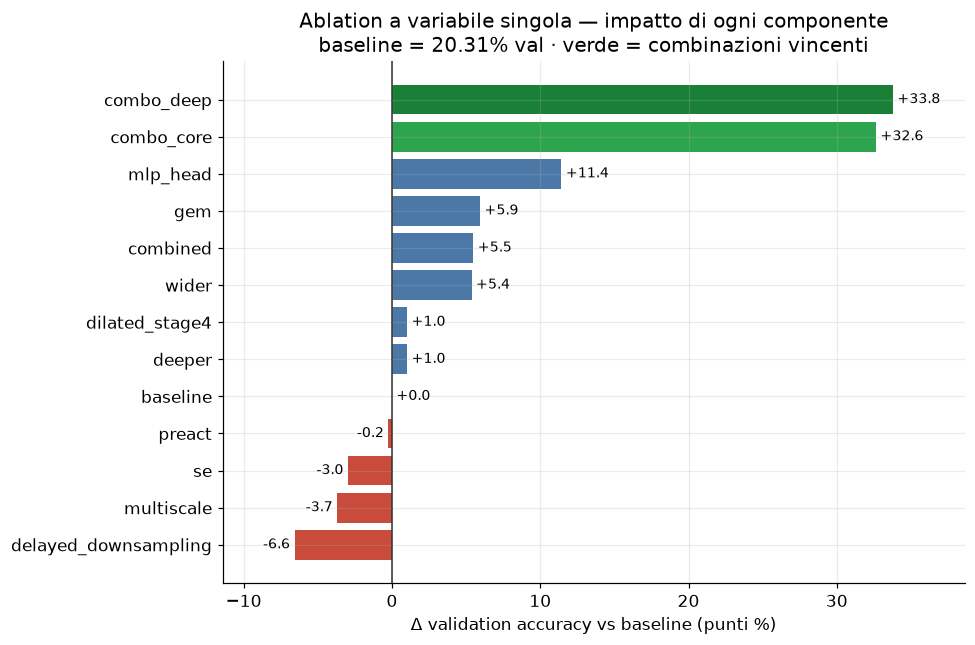

In [10]:
# Grafico dell'ablation: Δ accuracy vs baseline, colorato per esito.
order = tab.sort_values("best_val_accuracy")
labels = order.variant.str.replace(r"^\d+_", "", regex=True)
delta = (order.best_val_accuracy - base) * 100

def color(v, name):
    if name == "12_combo_deep": return "#1a7f37"      # vincitore
    if name == "11_combo_core": return "#2da44e"      # combo forte
    return "#4c78a8" if v >= 0 else "#c94b3b"          # positivo / negativo

colors = [color(v, n) for v, n in zip(delta, order.variant)]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(labels, delta, color=colors)
ax.axvline(0, color="#333", lw=1)
ax.set_xlabel("Δ validation accuracy vs baseline (punti %)")
ax.set_title("Ablation a variabile singola — impatto di ogni componente\n"
             "baseline = 20.31% val · verde = combinazioni vincenti")
for y, (v, name) in enumerate(zip(delta, order.variant)):
    ax.text(v + (0.3 if v >= 0 else -0.3), y, f"{v:+.1f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)
ax.margins(x=0.12)
plt.tight_layout()
plt.show()

### Perché la combinazione fa **53 %** e non 32 %

| Configurazione | Val acc |
|---|---|
| baseline | 20.31 % |
| miglior componente singolo (`mlp_head`) | 31.74 % |
| **`11_combo_core` = wider + gem + mlp_head** | **52.96 %** |
| **`12_combo_deep` = core + deeper + preact** | **54.10 %** |

La combinazione dei tre vincenti dà **+21 punti sul miglior singolo**: un effetto
**super-additivo** (la somma ingenua dei Δ isolati sarebbe ~+23 sul baseline ≈ 43 %; il reale
è ~53 %). Il motivo è l'**ortogonalità** — ognuno migliora uno stadio diverso e complementare:

```
[ backbone più ricco ] → [ aggregazione migliore ] → [ classificatore migliore ]
       wider                      gem                       mlp_head
  più feature discri-        le concentra sulle         traccia confini non
  minanti disponibili        regioni salienti           lineari tra classi vicine
```

Feature migliori sono inutili se il pooling le diluisce; un pooling migliore è sprecato se la
testa lineare non sa separarle. Insieme la catena non ha più anelli deboli. È l'opposto di
`10_combined` (25.80 %), che diluiva i vincenti con i **perdenti** (`se` −3.0, `multiscale`
−3.7) e ometteva l'`mlp_head`: **aggiungere componenti che interferiscono peggiora, aggiungere
componenti ortogonali compone.**

> Nota di onestà sperimentale: i componenti **non** vincenti (`se`, `multiscale`,
> `delayed_downsampling`, `dilated`) sono riportati comunque, a garanzia che lo studio non sia
> *cherry-picked*. Alcune idee tratte da paper noti non hanno retto su questo dataset piccolo.

## 6 · Calibrazione: dall'architettura al **62 %**

Congelata l'architettura (`12_combo_deep`), due diagnostiche dal run di ablation hanno guidato
la calibrazione dei **soli iperparametri di training**:

1. **best checkpoint @ epoca 39/40** → il modello era ancora in miglioramento → **allenare più
   a lungo** (80 epoche);
2. **gap train ~84 % vs val ~54 %** → overfitting → **più regolarizzazione** (il weight decay
   5e-4 era basso per AdamW).

Tre configurazioni, stesso seed, selezione su validation, test una sola volta sul migliore:

In [11]:
calib = pd.read_csv(ABL / "calibration" / "ranking.csv")
winner = json.loads((ABL / "calibration" / "winner.json").read_text(encoding="utf-8"))

view = calib.copy()
view["Val acc %"] = (view.best_val_accuracy * 100).round(2)
view["Gap train-val"] = (view.overfit_gap * 100).round(1)
view = view[["tag", "epochs", "lr", "wd", "Val acc %", "Gap train-val", "best_epoch"]]
print("Test accuracy del vincitore (long_wd), toccato una sola volta: "
      f"{winner['test_accuracy']*100:.2f}%\n")
view.reset_index(drop=True)

Test accuracy del vincitore (long_wd), toccato una sola volta: 62.47%



,tag,epochs,lr,wd,Val acc %,Gap train-val,best_epoch
0,long_wd,80,0.0004,0.0100,62.68,36.0,64
1,long_base,80,0.0004,0.0005,62.38,36.5,66
2,long_wd_lr,80,0.0006,0.0100,60.07,38.9,79


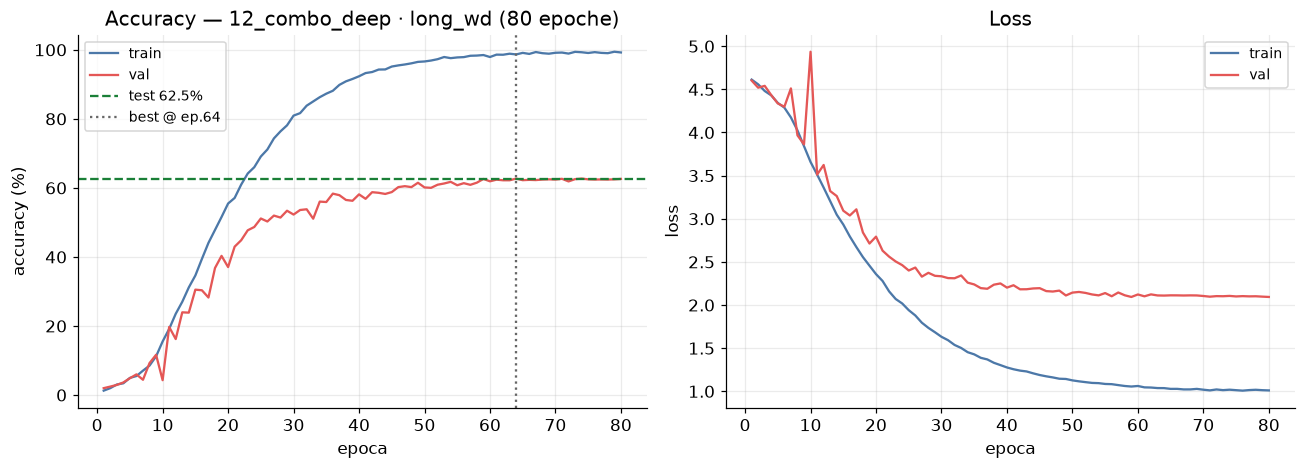

Val migliore 62.68% @ epoca 64 · train 98.7% · gap 36.0 pt


In [12]:
# Curve di training del modello vincente (long_wd), da history.csv reale.
hist = pd.read_csv(ABL / "calibration" / "long_wd" / "history.csv")
best_ep = int(winner["best_epoch"])
test_acc = winner["test_accuracy"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4))

a1.plot(hist.epoch, hist.train_accuracy * 100, label="train", color="#4c78a8")
a1.plot(hist.epoch, hist.val_accuracy * 100, label="val", color="#e45756")
a1.axhline(test_acc * 100, ls="--", color="#1a7f37", label=f"test {test_acc*100:.1f}%")
a1.axvline(best_ep, ls=":", color="#666", label=f"best @ ep.{best_ep}")
a1.set_xlabel("epoca"); a1.set_ylabel("accuracy (%)")
a1.set_title("Accuracy — 12_combo_deep · long_wd (80 epoche)")
a1.legend(fontsize=9)

a2.plot(hist.epoch, hist.train_loss, label="train", color="#4c78a8")
a2.plot(hist.epoch, hist.val_loss, label="val", color="#e45756")
a2.set_xlabel("epoca"); a2.set_ylabel("loss")
a2.set_title("Loss")
a2.legend(fontsize=9)

plt.tight_layout(); plt.show()

print(f"Val migliore {winner['best_val_accuracy']*100:.2f}% @ epoca {best_ep} · "
      f"train {winner['best_train_accuracy']*100:.1f}% · gap {winner['overfit_gap']*100:.1f} pt")

### Cosa ha spostato l'ago
- **La durata del training è la leva dominante.** Anche il solo controllo `long_base` (stessa
  regolarizzazione, solo 80 epoche) salta a **62.38 %**: il modello a 40 epoche era davvero
  troncato (best @ ep. 64–66 su 80). La diagnosi "best @ 39/40" era corretta.
- **weight_decay 1e-2** (da 5e-4): aiuto reale ma piccolo (**+0.30**, gap leggermente più
  stretto). Il valore 5e-4 era basso per AdamW, dove il decay disaccoppiato tipico è ~1e-2
  (Loshchilov & Hutter, *Decoupled Weight Decay Regularization*, **ICLR 2019**, arXiv:1711.05101).
- **lr 6e-4 peggiora** (60.07 %): si resta su 4e-4.

## 7 · Il percorso completo del guadagno

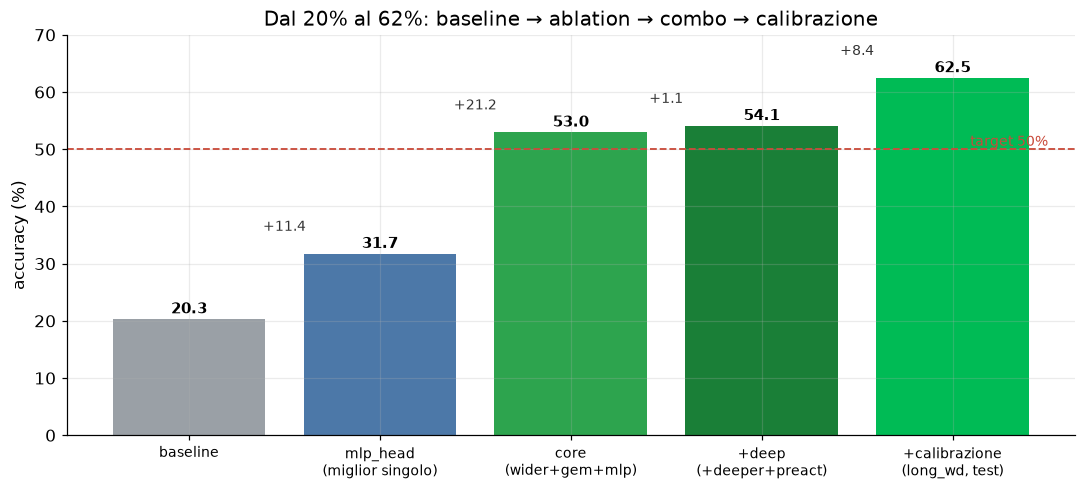

In [13]:
steps = ["baseline", "mlp_head\n(miglior singolo)", "core\n(wider+gem+mlp)",
         "+deep\n(+deeper+preact)", "+calibrazione\n(long_wd, test)"]
vals = [20.31, 31.74, 52.96, 54.10, 62.47]

fig, ax = plt.subplots(figsize=(10, 4.6))
bars = ax.bar(range(len(vals)), vals, color=["#9aa0a6", "#4c78a8", "#2da44e", "#1a7f37", "#0b5" ])
ax.axhline(50, ls="--", color="#c94b3b", lw=1.2)
ax.text(len(vals)-0.5, 50.6, "target 50%", color="#c94b3b", ha="right", fontsize=9)
ax.set_xticks(range(len(vals))); ax.set_xticklabels(steps, fontsize=9)
ax.set_ylabel("accuracy (%)"); ax.set_ylim(0, 70)
ax.set_title("Dal 20% al 62%: baseline → ablation → combo → calibrazione")
for i, v in enumerate(vals):
    ax.text(i, v + 1, f"{v:.1f}", ha="center", fontsize=10, fontweight="bold")
for i in range(1, len(vals)):
    ax.annotate(f"+{vals[i]-vals[i-1]:.1f}", (i-0.5, max(vals[i], vals[i-1])+4),
                ha="center", color="#333", fontsize=9)
plt.tight_layout(); plt.show()

### Osservazioni finali e limite residuo
- **Target 50 % superato** sul test set (**62.47 %**), il numero che conta per l'assignment.
- **Val ≈ test** (62.68 vs 62.47 %): il modello generalizza e il ranking su validation è
  affidabile, nessun bias da selezione.
- **Overfitting residuo:** il gap train–val resta **~36 punti** (train ~99 % vs val ~62 %). Il
  weight decay agisce sui *pesi* e lo scalfisce appena; il modello **memorizza** le ~3 300
  immagini. La leva successiva è la regolarizzazione sui **dati**: augmentation più forte, in
  particolare **MixUp** (Zhang et al., ICLR 2018) e **CutMix** (Yun et al., ICCV 2019) —
  entrambe **trattate in L6**, quindi pienamente course-grounded — idealmente su GPU ora che
  l'architettura è fissata.

## 8 · Coerenza con il corso — cosa è sulle slide e cosa no

Verificato **direttamente sui PDF** (`theory/IPCV_P2L5_architectures.pdf`,
`theory/IPCV_P2L6_regularization_and_training_recipes.pdf`). La stragrande maggioranza dei
componenti è **coperta dal corso**; **solo due** elementi del modello vincente sono *oltre le
slide* e sono giustificati con il paper di riferimento.

In [14]:
rows = [
    # componente, stato, riferimento
    ("Stem 3×3×3 (ResNet-C)",          "Corso · L5", "He et al., Bag of Tricks, CVPR 2019"),
    ("Blocchi/stage residuali",         "Corso · L5", "He et al., Deep Residual Learning, CVPR 2016"),
    ("Larghezza (wider)",               "Corso · L5/L6", "Zagoruyko & Komodakis, WRN, BMVC 2016 (tesi width>depth)"),
    ("Profondità (deeper)",             "Corso · L5", "ResNet-18/34, He et al. 2016"),
    ("Global Average Pooling",          "Corso · L5", "Lin et al., Network in Network, ICLR 2014"),
    ("Testa MLP non lineare",           "Corso · L5", "AlexNet/VGG multi-FC; extra: SimCLR, ICML 2020"),
    ("BatchNorm / Dropout",             "Corso · L6", "Ioffe&Szegedy 2015 / Srivastava et al. 2014"),
    ("Label smoothing 0.1",             "Corso · L6", "Szegedy et al., Rethinking Inception, CVPR 2016"),
    ("Weight decay / AdamW",            "Corso · L6", "Loshchilov & Hutter, AdamW, ICLR 2019"),
    ("Cosine LR / early stopping",      "Corso · L6", "L6 training recipes"),
    ("Augmentation (crop/erasing)",     "Corso · L6", "Zhong et al., Random Erasing, AAAI 2020"),
    ("MixUp / CutMix (leva futura)",    "Corso · L6", "Zhang et al. 2018 / Yun et al. 2019"),
    ("GeM pooling",                     "OLTRE IL CORSO", "Radenović, Tolias, Chum, IEEE TPAMI 2019 (arXiv:1711.02512)"),
    ("Pre-activation (ResNet-v2)",      "OLTRE IL CORSO", "He et al., Identity Mappings in Deep ResNets, ECCV 2016 (arXiv:1603.05027)"),
]
coh = pd.DataFrame(rows, columns=["Componente", "Stato", "Riferimento"])
coh

,Componente,Stato,Riferimento
0,Stem 3×3×3 (ResNet-C),Corso · L5,"He et al., Bag of Tricks, CVPR 2019"
1,Blocchi/stage residuali,Corso · L5,"He et al., Deep Residual Learning, CVPR 2016"
2,Larghezza (wider),Corso · L5/L6,"Zagoruyko & Komodakis, WRN, BMVC 2016 (tesi wi..."
3,Profondità (deeper),Corso · L5,"ResNet-18/34, He et al. 2016"
4,Global Average Pooling,Corso · L5,"Lin et al., Network in Network, ICLR 2014"
5,Testa MLP non lineare,Corso · L5,"AlexNet/VGG multi-FC; extra: SimCLR, ICML 2020"
6,BatchNorm / Dropout,Corso · L6,Ioffe&Szegedy 2015 / Srivastava et al. 2014
7,Label smoothing 0.1,Corso · L6,"Szegedy et al., Rethinking Inception, CVPR 2016"
8,Weight decay / AdamW,Corso · L6,"Loshchilov & Hutter, AdamW, ICLR 2019"
9,Cosine LR / early stopping,Corso · L6,L6 training recipes


### Verifica testuale sulle slide (grep sui PDF)

Estraendo il testo dei PDF con `pymupdf`, i termini **`GeM` / `generalized mean` /
`pre-activation` / `identity mapping` risultano ASSENTI** sia in L5 sia in L6, mentre `global
average pooling`, `width`, `label smoothing`, `weight decay`, `dropout`, `cosine`, `mixup`,
`cutmix`, `random erasing` sono **presenti**. Questo conferma la tabella: i due unici elementi
"oltre il corso" del vincitore sono **GeM pooling** e **pre-activation**, entrambi citati con
il rispettivo paper.

In [15]:
# Verifica riproducibile: quali termini compaiono nei PDF del corso.
try:
    import fitz  # pymupdf
    terms = ["gem", "generalized mean", "pre-activation", "identity mapping",
             "global average", "width", "label smoothing", "weight decay",
             "dropout", "cosine", "mixup", "cutmix", "random erasing"]
    for pdf in ["IPCV_P2L5_architectures.pdf", "IPCV_P2L6_regularization_and_training_recipes.pdf"]:
        path = ROOT.parent / "theory" / pdf
        if not path.exists():
            print(f"(PDF non trovato: {path})"); continue
        text = " ".join(p.get_text() for p in fitz.open(path)).lower()
        print(f"\n{pdf}")
        for t in terms:
            print(f"  {t:18} {'PRESENTE' if t in text else '— assente'}")
except ImportError:
    print("pymupdf non installato: pip install pymupdf per rieseguire questa verifica.")


IPCV_P2L5_architectures.pdf
  gem                — assente
  generalized mean   — assente
  pre-activation     — assente
  identity mapping   — assente
  global average     PRESENTE
  width              PRESENTE
  label smoothing    — assente
  weight decay       — assente
  dropout            — assente
  cosine             — assente
  mixup              — assente
  cutmix             — assente
  random erasing     — assente

IPCV_P2L6_regularization_and_training_recipes.pdf
  gem                — assente
  generalized mean   — assente
  pre-activation     — assente
  identity mapping   — assente
  global average     PRESENTE
  width              PRESENTE
  label smoothing    PRESENTE
  weight decay       PRESENTE
  dropout            PRESENTE
  cosine             PRESENTE
  mixup              PRESENTE
  cutmix             PRESENTE
  random erasing     PRESENTE


## 9 · Come riprodurre i risultati

Gli esperimenti richiedono una GPU (~10 min a run di ablation, ~19 min a config di
calibrazione su RTX 5060 Ti). I comandi, dalla root del progetto:

```bash
# 1) Ablation completa (13 varianti) + ranking su validation
python -m sandbox.architecture_ablation.run_experiments --variants all --epochs 40

# 2) Valuta il vincitore dell'ablation sul test set (una sola volta)
python -m sandbox.architecture_ablation.run_experiments --evaluate-winner

# 3) Calibrazione degli iperparametri sull'architettura congelata 12_combo_deep
python -m sandbox.architecture_ablation.calibrate
```

Gli artefatti prodotti (e già presenti nel repo, usati da questo notebook):
`sandbox/architecture_ablation/runs/<variante>/{history.csv,result.json,best_model.pt}`,
`.../final_result/{ranking.csv,winner.json}`,
`.../calibration/<config>/{history.csv,result.json,best_model.pt}` e `.../calibration/winner.json`.

### Valutazione opzionale del checkpoint finale (62.47 %)
La cella seguente ricarica i **pesi salvati** del modello vincente e li rivaluta sul test set.
È **disattivata di default** (`REPRODUCE_TEST = False`) perché su CPU è lenta; su GPU
richiede pochi secondi. I `data/fgvc-aircraft/data/images` completi (10 000 jpg) devono essere
presenti.

In [16]:
REPRODUCE_TEST = False  # -> True per rivalutare i pesi salvati sul test set (serve il dataset completo)

if REPRODUCE_TEST:
    from torch.utils.data import DataLoader
    from torch import nn
    from cnn_library.data import FGVCAircraftDataset
    from sandbox.refinements.resnet_aircraft_experiment import run_epoch

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    m = build_model("12_combo_deep").to(device)
    ckpt = torch.load(ABL / "calibration" / "long_wd" / "best_model.pt", map_location=device)
    m.load_state_dict(ckpt["model_state"])

    _, eval_tf = build_transforms(224)
    test_loader = DataLoader(
        FGVCAircraftDataset(str(ROOT / "data" / "fgvc-aircraft"), "test", eval_tf),
        batch_size=64, shuffle=False,
    )
    loss, acc = run_epoch(m, test_loader, nn.CrossEntropyLoss(label_smoothing=0.1),
                          device, amp=device.type == "cuda")
    print(f"Test accuracy (ricalcolata): {acc*100:.2f}%  ·  loss {loss:.4f}")
else:
    print("REPRODUCE_TEST=False — risultato salvato: test accuracy 62.47% (calibration/winner.json)")

REPRODUCE_TEST=False — risultato salvato: test accuracy 62.47% (calibration/winner.json)


---
### Riepilogo
`12_combo_deep` (from-scratch, 8.07 M param) allenato con il protocollo `long_wd` raggiunge
**62.47 % di test accuracy** su FGVC-Aircraft (100 classi), superando il target del 50 %. Il
risultato nasce da un ablation study controllato che isola tre scelte ortogonali e vincenti
(**larghezza**, **GeM pooling**, **testa MLP**), rafforzate da **profondità + pre-activation**,
e da una calibrazione guidata dalla diagnosi dell'overfitting. Tutte le scelte sono coperte
dalle lezioni L5–L6, tranne **GeM pooling** e **pre-activation**, giustificate con i rispettivi
paper. La leva residua per superare il 62 % è la regolarizzazione sui dati (**MixUp/CutMix**),
anch'essa nel programma del corso.